# Unemployment Analysis in India (with COVID-19 Impact)

**Goal:** Clean and explore monthly unemployment data across Indian states/UTs (May 2019 – June
2020), visualize trends, quantify the impact of the COVID-19 lockdown, surface seasonal/regional
patterns, and translate the findings into policy-relevant insights.

**Dataset columns:**
- `Region` — State / Union Territory
- `Date` — Reporting month
- `Frequency` — Reporting frequency (Monthly)
- `Estimated Unemployment Rate (%)` — % of labour force unemployed
- `Estimated Employed` — Number of people employed
- `Estimated Labour Participation Rate (%)` — % of population in the labour force
- `Area` — Rural / Urban breakdown

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


## 2. Load & Clean the Data

Raw data quirks to handle:
- Column names have leading/trailing whitespace (and a BOM on the first column).
- Some rows are entirely blank (no data at all) and should be dropped.
- `Date` is stored as text and needs parsing into an actual datetime.
- Categorical text columns (`Region`, `Frequency`, `Area`) have stray whitespace.

In [2]:
df = pd.read_csv("Unemployment_in_India.csv")

print("Raw shape:", df.shape)
df.head()


Raw shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# --- Clean column names ---
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())


['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [4]:
# --- Drop fully-empty rows ---
print("Fully-null rows:", df.isna().all(axis=1).sum())
df = df.dropna(how="all").reset_index(drop=True)
print("Shape after dropping empty rows:", df.shape)


Fully-null rows: 28
Shape after dropping empty rows: (740, 7)


In [5]:
# --- Strip whitespace from text columns ---
text_cols = ["Region", "Date", "Frequency", "Area"]
for c in text_cols:
    df[c] = df[c].str.strip()

# --- Parse Date ---
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# --- Rename long columns for convenience ---
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})

# --- Add helper time columns ---
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["YearMonth"] = df["Date"].dt.to_period("M")

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    str           
 1   Date                       740 non-null    datetime64[us]
 2   Frequency                  740 non-null    str           
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    str           
 7   Year                       740 non-null    int32         
 8   Month                      740 non-null    int32         
 9   Month_Name                 740 non-null    str           
 10  YearMonth                  740 non-null    period[M]     
dtypes: datetime64[us](1), float64(3), int32(2), period[M](1), str(4)
memory usage: 57.

In [6]:
# Sanity checks
print("Any remaining nulls?\n", df.isna().sum())
print("\nDate range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("\nRegions:", df["Region"].nunique())
print("Areas:", df["Area"].unique())


Any remaining nulls?
 Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Year                         0
Month                        0
Month_Name                   0
YearMonth                    0
dtype: int64

Date range: 2019-05-31 to 2020-06-30

Regions: 28
Areas: <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str


In [7]:
df.describe()


,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Year,Month
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122,2019.418919,6.390541
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000,1.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000,4.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000,6.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000,9.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000,12.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716,3.235070


In [8]:
df.head()


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month,Month_Name,YearMonth
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,Jun,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,Jul,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,Aug,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,Sep,2019-09


## 3. Overall Unemployment Trend Over Time

We start with the national picture: average unemployment rate across all regions, month by
month, split by Rural vs Urban.

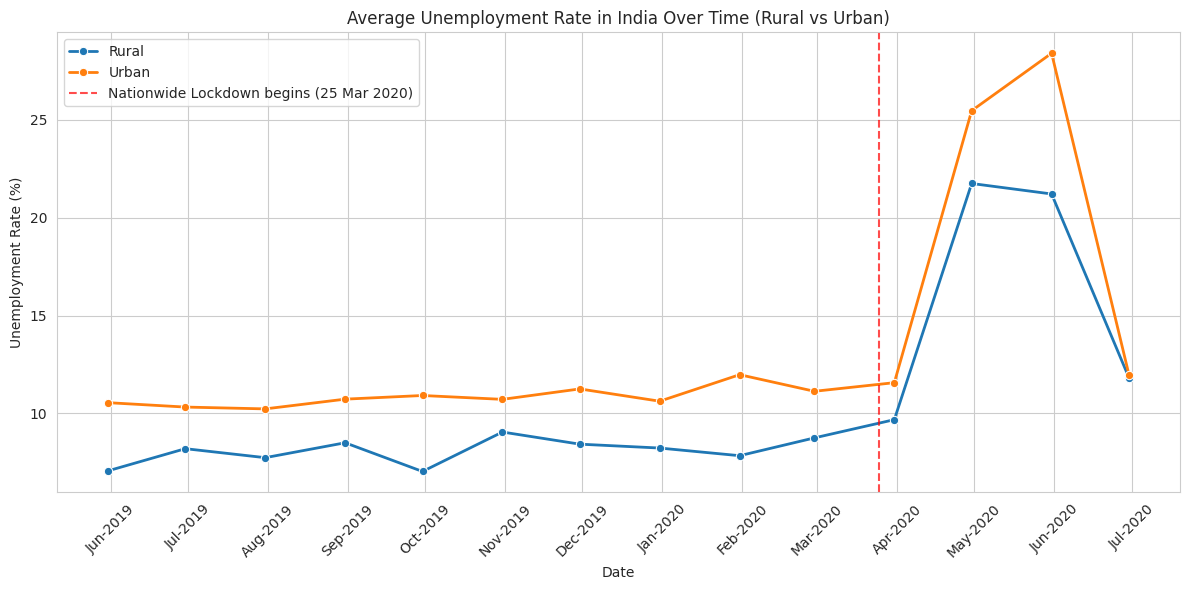

In [9]:
monthly_avg = df.groupby(["Date", "Area"])["Unemployment_Rate"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x="Date", y="Unemployment_Rate", hue="Area", marker="o", linewidth=2)
plt.title("Average Unemployment Rate in India Over Time (Rural vs Urban)")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Date")
plt.axvline(pd.Timestamp("2020-03-25"), color="red", linestyle="--", alpha=0.7,
            label="Nationwide Lockdown begins (25 Mar 2020)")
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Unemployment hovers in a fairly stable band (roughly 5-9%) throughout 2019
and early 2020. Then there's a dramatic, near-vertical spike starting around March/April 2020 —
right when India's COVID-19 lockdown was announced — before beginning to recover by mid-2020.
Urban areas show a sharper spike than rural areas.

## 4. Quantifying the COVID-19 Impact

Let's directly compare the **pre-COVID period** (before March 2020) to the **COVID period**
(March 2020 onward, when the lockdown began) to quantify the shock.

In [10]:
covid_start = pd.Timestamp("2020-03-01")
df["Period"] = np.where(df["Date"] < covid_start, "Pre-COVID", "COVID Period")

period_summary = df.groupby("Period")["Unemployment_Rate"].agg(["mean", "median", "max", "std"]).round(2)
period_summary = period_summary.reindex(["Pre-COVID", "COVID Period"])
period_summary


,mean,median,max,std
Period,,,,
Pre-COVID,9.51,7.12,34.69,7.36
COVID Period,17.77,14.52,76.74,15.03


/tmp/ipykernel_644/3727558640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Period", y="Unemployment_Rate", order=["Pre-COVID", "COVID Period"], palette="Set2")


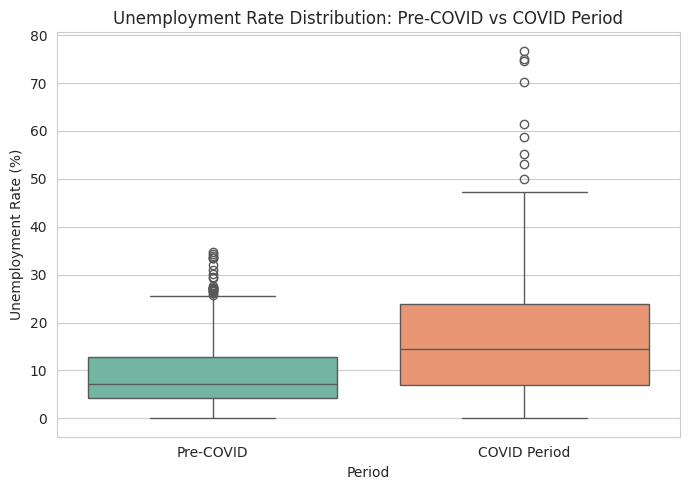

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Period", y="Unemployment_Rate", order=["Pre-COVID", "COVID Period"], palette="Set2")
plt.title("Unemployment Rate Distribution: Pre-COVID vs COVID Period")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()


In [12]:
pre_covid_mean = df.loc[df["Period"] == "Pre-COVID", "Unemployment_Rate"].mean()
covid_mean = df.loc[df["Period"] == "COVID Period", "Unemployment_Rate"].mean()
pct_increase = (covid_mean - pre_covid_mean) / pre_covid_mean * 100

print(f"Pre-COVID average unemployment rate: {pre_covid_mean:.2f}%")
print(f"COVID-period average unemployment rate: {covid_mean:.2f}%")
print(f"Relative increase: {pct_increase:.1f}%")


Pre-COVID average unemployment rate: 9.51%
COVID-period average unemployment rate: 17.77%
Relative increase: 86.9%


In [13]:
# Peak month nationally
monthly_national = df.groupby("Date")["Unemployment_Rate"].mean()
peak_date = monthly_national.idxmax()
peak_value = monthly_national.max()
print(f"Peak unemployment month: {peak_date.strftime('%B %Y')} at {peak_value:.2f}%")


Peak unemployment month: May 2020 at 24.88%


**Observation:** The COVID-19 lockdown period shows a sharply higher average unemployment
rate than the pre-COVID baseline, with the single worst month being the initial lockdown month —
consistent with the sudden halt of economic activity, transport, and informal-sector work.

## 5. Rural vs Urban: Who Was Hit Harder?

In [14]:
area_period = df.groupby(["Period", "Area"])["Unemployment_Rate"].mean().reset_index()
area_period_pivot = area_period.pivot(index="Period", columns="Area", values="Unemployment_Rate").reindex(["Pre-COVID", "COVID Period"])
area_period_pivot


Area,Rural,Urban
Period,,
Pre-COVID,8.094808,10.842246
COVID Period,16.181313,19.276381


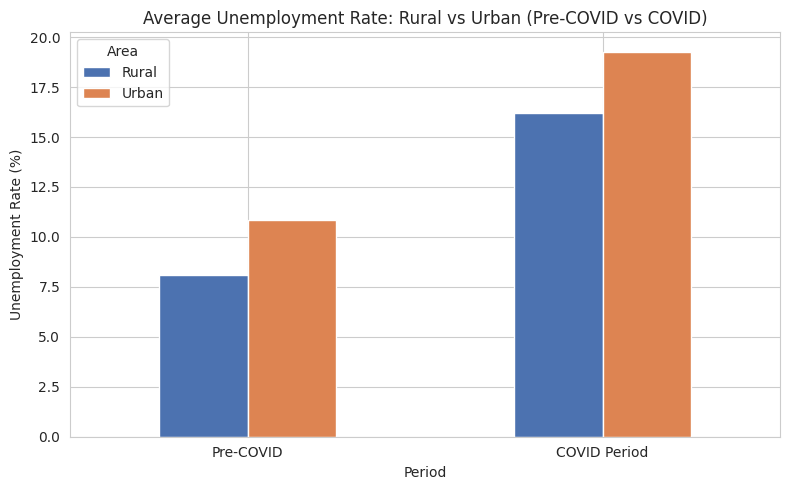

In [15]:
ax = area_period_pivot[["Rural", "Urban"]].plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
plt.title("Average Unemployment Rate: Rural vs Urban (Pre-COVID vs COVID)")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Area")
plt.tight_layout()
plt.show()


**Observation:** Urban unemployment typically jumps higher than rural during the lockdown
peak. This lines up with how India's lockdown most severely disrupted urban/formal-sector jobs,
transport, and services, while a portion of rural/agricultural work continued (and some migrant
workers returned to rural areas, complicating rural figures too).

## 6. State-Level Impact: Who Was Hit Hardest?

Let's identify which states/regions saw the largest jump in unemployment rate from before COVID
to during COVID.

In [16]:
state_period = df.groupby(["Region", "Period"])["Unemployment_Rate"].mean().unstack()
state_period = state_period.reindex(columns=["Pre-COVID", "COVID Period"])
state_period["Increase (pp)"] = state_period["COVID Period"] - state_period["Pre-COVID"]
state_period = state_period.sort_values("Increase (pp)", ascending=False)

top_10_hit = state_period.head(10)
top_10_hit


Period,Pre-COVID,COVID Period,Increase (pp)
Region,,,
Puducherry,1.5930,38.95500,37.36200
Tamil Nadu,2.8365,25.40375,22.56725
Jharkhand,14.2795,36.34875,22.06925
Bihar,13.8330,31.63125,17.79825
Karnataka,3.2345,15.28000,12.04550
Haryana,22.9355,34.65250,11.71700
Kerala,6.9925,17.95250,10.96000
Telangana,4.6560,15.44250,10.78650
Madhya Pradesh,4.7410,14.07000,9.32900


/tmp/ipykernel_644/899832108.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_hit["Increase (pp)"], y=top_10_hit.index, palette="Reds_r")


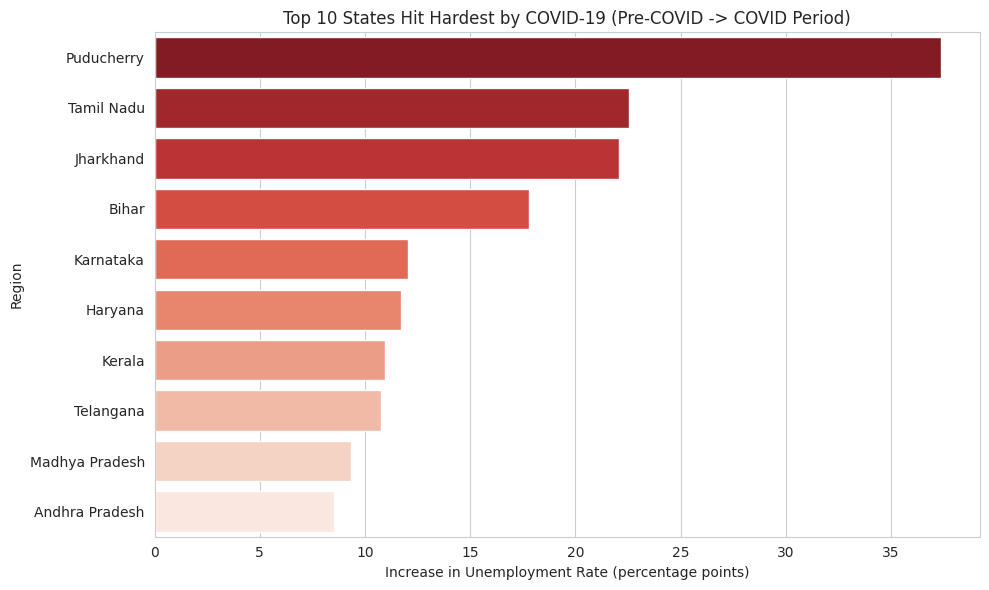

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_hit["Increase (pp)"], y=top_10_hit.index, palette="Reds_r")
plt.xlabel("Increase in Unemployment Rate (percentage points)")
plt.title("Top 10 States Hit Hardest by COVID-19 (Pre-COVID -> COVID Period)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_644/3378002464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=least_affected["Increase (pp)"], y=least_affected.index, palette="Greens_r")


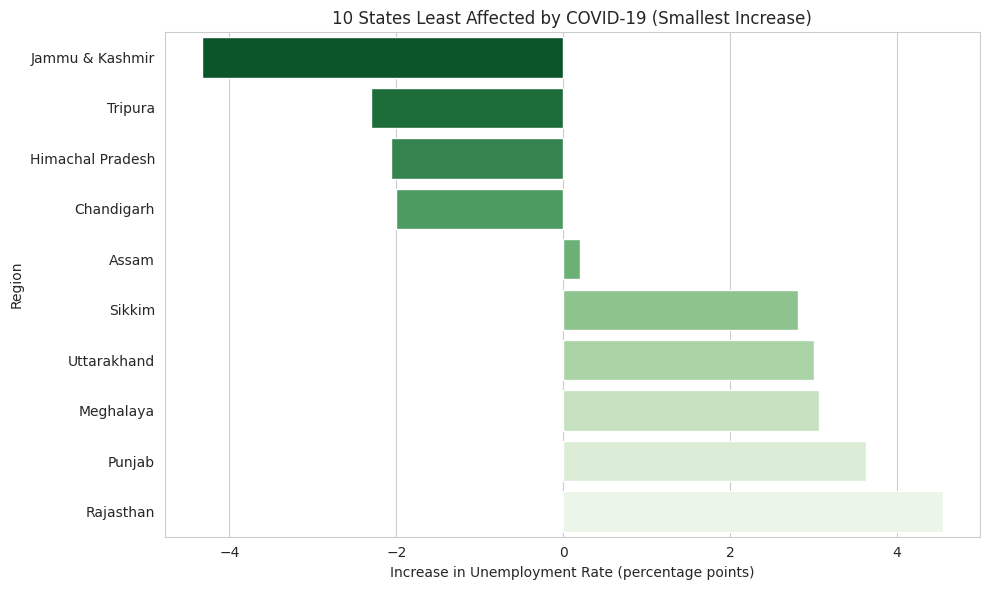

In [18]:
least_affected = state_period.sort_values("Increase (pp)").head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=least_affected["Increase (pp)"], y=least_affected.index, palette="Greens_r")
plt.xlabel("Increase in Unemployment Rate (percentage points)")
plt.title("10 States Least Affected by COVID-19 (Smallest Increase)")
plt.tight_layout()
plt.show()


**Observation:** The impact was far from uniform — some states saw unemployment spike by
tens of percentage points, while others were comparatively insulated. This regional variation
likely reflects differences in dependence on urban/industrial employment vs agriculture, the
severity and duration of local lockdown restrictions, and the size of the informal economy in
each state.

## 7. Seasonal Patterns (Pre-COVID Baseline)

To separate "COVID shock" from "normal seasonality," let's look at month-by-month unemployment
using only the pre-COVID data (May 2019 - Feb 2020), which reflects the *typical* seasonal cycle
without the pandemic shock.

/tmp/ipykernel_644/648777003.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_labels, y=seasonal.values, palette="coolwarm")


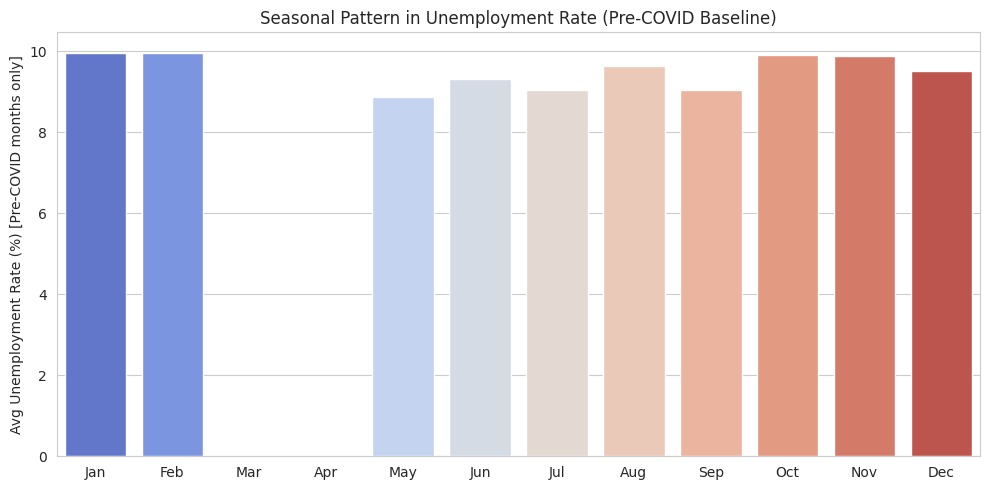

In [19]:
pre_covid_df = df[df["Period"] == "Pre-COVID"]

seasonal = pre_covid_df.groupby("Month")["Unemployment_Rate"].mean().reindex(range(1, 13))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
sns.barplot(x=month_labels, y=seasonal.values, palette="coolwarm")
plt.ylabel("Avg Unemployment Rate (%) [Pre-COVID months only]")
plt.title("Seasonal Pattern in Unemployment Rate (Pre-COVID Baseline)")
plt.tight_layout()
plt.show()


**Observation:** Even before COVID, unemployment isn't perfectly flat across the year —
there's a mild seasonal rhythm tied to agricultural cycles (harvest vs sowing seasons) and
post-monsoon labour demand. This baseline seasonality is far smaller than the COVID-driven spike,
which confirms the 2020 jump is a genuine shock rather than normal seasonal variation.

## 8. Unemployment vs Labour Participation Rate

A rising unemployment rate can sometimes coincide with people leaving the labour force entirely
(discouraged workers) rather than just more people being unemployed. Let's check how Labour
Participation Rate moved alongside Unemployment Rate.

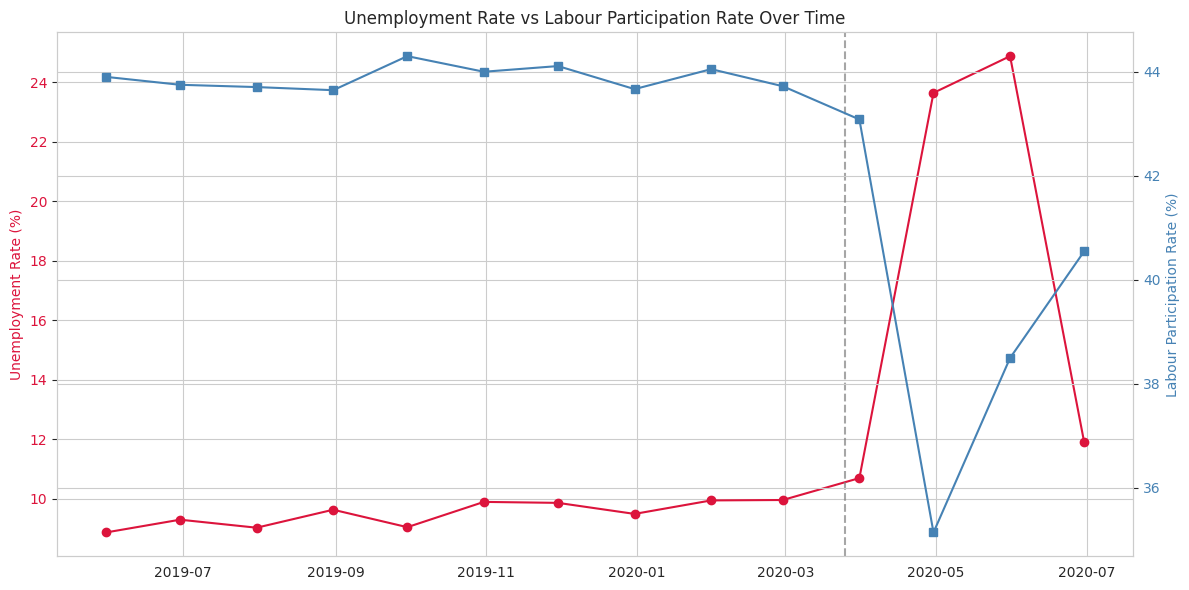

In [20]:
monthly_combo = df.groupby("Date")[["Unemployment_Rate", "Labour_Participation_Rate"]].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(monthly_combo.index, monthly_combo["Unemployment_Rate"], color="crimson", marker="o", label="Unemployment Rate (%)")
ax1.set_ylabel("Unemployment Rate (%)", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

ax2 = ax1.twinx()
ax2.plot(monthly_combo.index, monthly_combo["Labour_Participation_Rate"], color="steelblue", marker="s", label="Labour Participation Rate (%)")
ax2.set_ylabel("Labour Participation Rate (%)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax1.axvline(pd.Timestamp("2020-03-25"), color="gray", linestyle="--", alpha=0.7)
plt.title("Unemployment Rate vs Labour Participation Rate Over Time")
fig.tight_layout()
plt.show()


**Observation:** If Labour Participation Rate dropped at the same time Unemployment Rate
spiked, that suggests some people simply stopped looking for work (exited the labour force)
rather than actively searching and failing to find it — an important nuance for interpreting the
headline unemployment number during the lockdown.

## 9. Employment Numbers: The Other Side of the Story

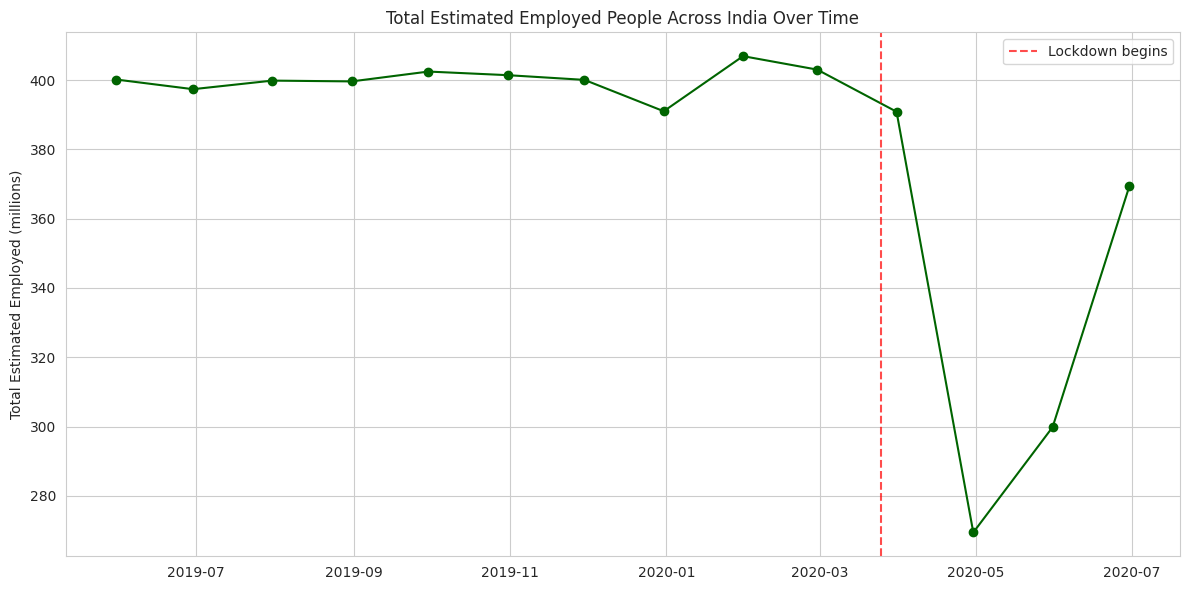

In [21]:
monthly_employed = df.groupby("Date")["Employed"].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_employed.index, monthly_employed.values / 1e6, marker="o", color="darkgreen")
plt.axvline(pd.Timestamp("2020-03-25"), color="red", linestyle="--", alpha=0.7, label="Lockdown begins")
plt.ylabel("Total Estimated Employed (millions)")
plt.title("Total Estimated Employed People Across India Over Time")
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** The total number of employed people (summed across reported regions) drops
noticeably during the lockdown months, reinforcing the unemployment rate spike — millions of jobs
were lost or paused in a very short window.

## 10. Key Patterns Summary (Heatmap View)

A region x month heatmap makes it easy to see exactly when and where unemployment spiked.

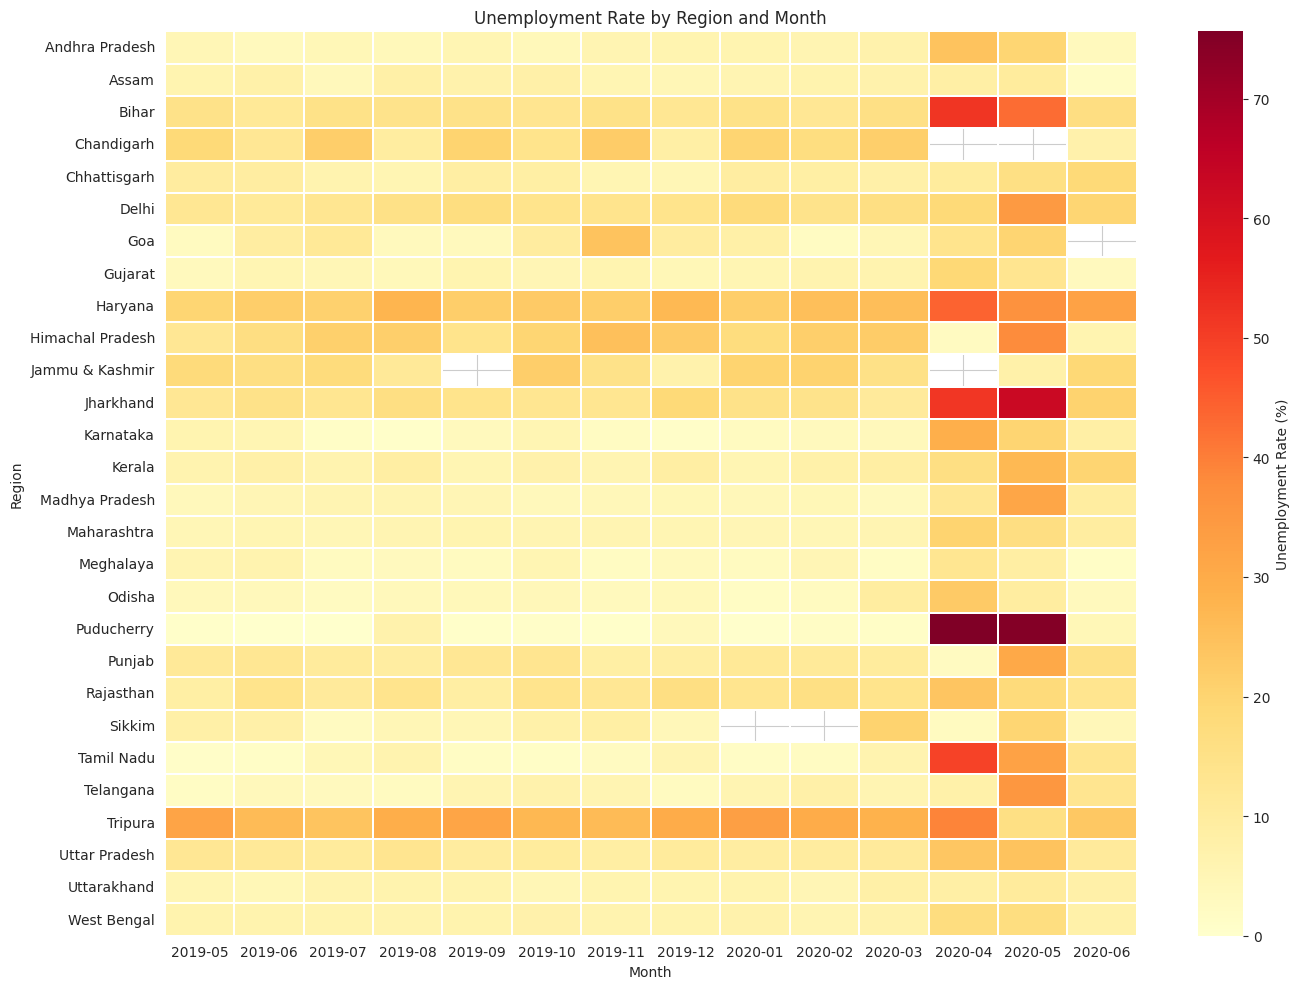

In [22]:
heatmap_data = df.groupby(["Region", "YearMonth"])["Unemployment_Rate"].mean().unstack()
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "Unemployment Rate (%)"})
plt.title("Unemployment Rate by Region and Month")
plt.xlabel("Month")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


**Observation:** The heatmap makes the COVID shock visually obvious as a bright vertical
band around April-May 2020 cutting across almost every region — confirming this was a broad,
nationwide shock rather than a localized issue, even though the *intensity* varied by state.

## 11. Key Insights & Policy Implications

Based on the analysis above:

1. **The COVID-19 lockdown caused an unprecedented, sudden unemployment shock.** Unemployment
   rates that were stable in the 5-9% range pre-pandemic spiked dramatically in April 2020 —
   far beyond any pre-COVID seasonal fluctuation. This points to the need for **rapid-response
   social safety nets** (emergency unemployment benefits, direct cash transfers) that can be
   activated quickly during sudden economy-wide shocks, rather than relying solely on
   slower-moving structural welfare programs.

2. **Urban areas were hit harder than rural areas during the peak**, likely due to reliance on
   formal employment, services, and transport-dependent jobs that halted completely. Policy
   should prioritize **urban informal-sector support** (street vendors, daily-wage workers,
   gig workers) who lack the safety net of salaried employment.

3. **The impact was highly uneven across states.** Some states saw far larger spikes than
   others. This suggests **targeted, state-specific recovery packages** would be more effective
   than a uniform national policy — states with high spikes likely have larger informal/urban
   workforces or were under stricter/longer lockdowns.

4. **A normal seasonal cycle exists independent of COVID**, tied to agricultural calendars.
   Policymakers should distinguish this baseline seasonal unemployment (which is predictable and
   manageable) from genuine economic shocks (which require emergency intervention) — i.e.,
   build models that account for seasonality before flagging a "crisis."

5. **Labour participation and unemployment should be read together.** A spike in the
   unemployment rate alone may understate the real damage if people are also leaving the labour
   force discouraged — both indicators should be monitored jointly for an accurate read on the
   true labour market health.

6. **Recovery began within a few months**, suggesting the shock — while severe — was largely
   driven by temporary lockdown restrictions rather than permanent structural collapse. This
   supports policies aimed at **bridging households through the shock** (temporary relief)
   rather than long-term restructuring, though continued monitoring is needed to confirm the
   recovery holds.

These patterns are consistent with what's been widely reported about India's COVID-19 economic
impact, and this kind of region/time-disaggregated view is exactly what allows policymakers to
target relief efficiently rather than spreading limited resources thinly and uniformly.